In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# notebook は EXP017/notebook/ にあるので親2つ上がプロジェクトルート
ROOT = Path().resolve().parents[1]
print(f'Project root: {ROOT}')

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History


In [2]:
# ---- 設定 ----------------------------------------------------------------
bank_id    = 1
prior      = 'normal'
KEY_STEPS  = [10, 20, 30, 40]   # テーブル表示するステップ

exp007_dir = ROOT / 'EXP007' / 'results'
exp017_dir = ROOT / 'EXP017' / 'results'

mfi_path = exp007_dir / f'summary_uncor_{bank_id}_MFI.csv'

# EXP007 / EXP017 で利用可能な gamma を自動収集
pat = re.compile(rf'summary_uncor_{bank_id}_DQN_{prior}_gamma_(.+)\.csv')

def find_gammas(directory: Path) -> dict:
    return {
        pat.match(p.name).group(1): p
        for p in sorted(directory.glob(f'summary_uncor_{bank_id}_DQN_{prior}_gamma_*.csv'))
        if pat.match(p.name)
    }

exp007_files = find_gammas(exp007_dir)
exp017_files = find_gammas(exp017_dir)

print(f'EXP007 gammas : {list(exp007_files.keys())}')
print(f'EXP017 gammas : {list(exp017_files.keys())}')

mfi = pd.read_csv(mfi_path)
print(f'MFI loaded    : {mfi_path}')

EXP007 gammas : ['0.1', '0.3', '0.6', '0.9']
EXP017 gammas : ['0.1']
MFI loaded    : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP007/results/summary_uncor_1_MFI.csv


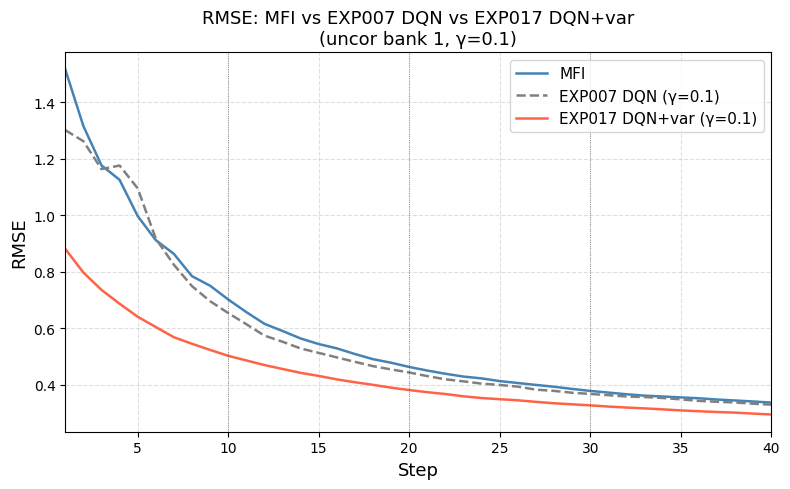

Saved → /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP017/results/rmse_comparison_uncor_1_gamma_0.1.png


In [3]:
# ---- 共通の gamma（両実験で結果がある gamma）を対象に 1 枚ずつプロット ----
common_gammas = sorted(
    set(exp007_files) & set(exp017_files),
    key=float,
)

out_dir = exp017_dir
out_dir.mkdir(parents=True, exist_ok=True)

for gamma in common_gammas:
    dqn007 = pd.read_csv(exp007_files[gamma])
    dqn017 = pd.read_csv(exp017_files[gamma])

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(mfi['step'],    mfi['RMSE'],    label='MFI',
            color='steelblue', linewidth=1.8)
    ax.plot(dqn007['step'], dqn007['RMSE'], label=f'EXP007 DQN (γ={gamma})',
            color='gray',      linewidth=1.8, linestyle='--')
    ax.plot(dqn017['step'], dqn017['RMSE'], label=f'EXP017 DQN+var (γ={gamma})',
            color='tomato',    linewidth=1.8)

    # key steps に縦線
    for s in KEY_STEPS:
        ax.axvline(s, color='black', linewidth=0.6, linestyle=':', alpha=0.5)

    ax.set_xlabel('Step', fontsize=13)
    ax.set_ylabel('RMSE', fontsize=13)
    ax.set_title(
        f'RMSE: MFI vs EXP007 DQN vs EXP017 DQN+var'
        f'\n(uncor bank {bank_id}, γ={gamma})',
        fontsize=13,
    )
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.set_xlim(1, max(dqn007['step'].max(), dqn017['step'].max()))

    plt.tight_layout()
    out_path = out_dir / f'rmse_comparison_uncor_{bank_id}_gamma_{gamma}.png'
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f'Saved → {out_path}')

/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/itsuki/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/itsuki/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.

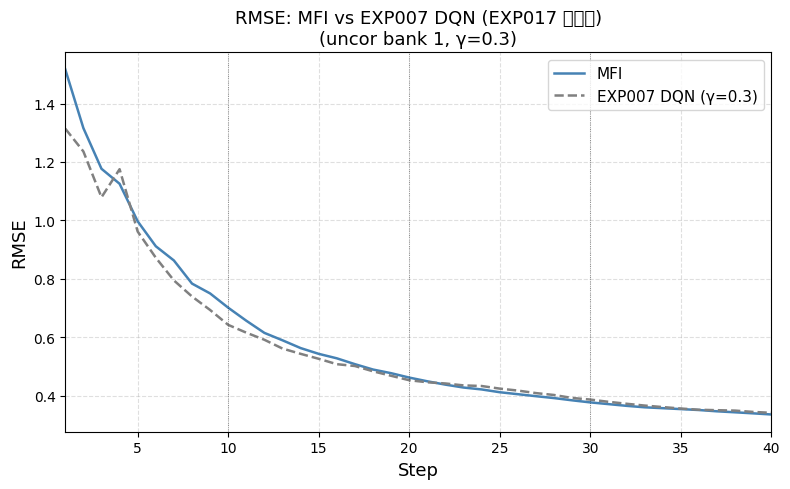

/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/itsuki/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/itsuki/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.

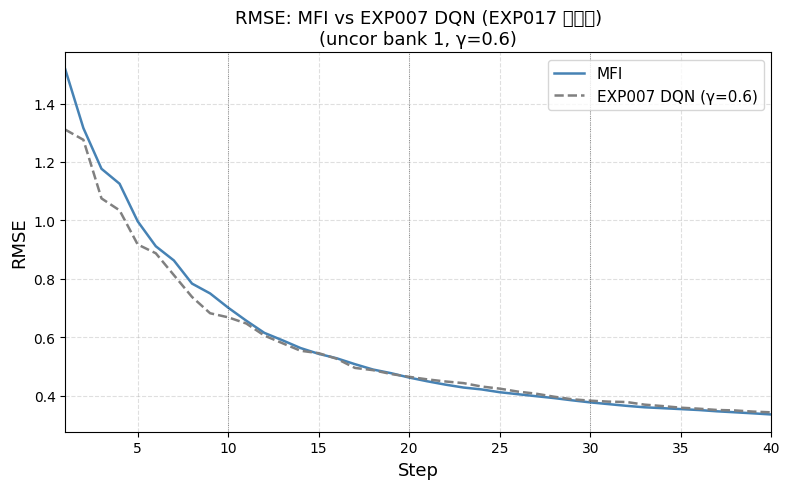

/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/my/jbvs6wq545z_39fwwyf02mfw0000gn/T/ipykernel_43853/1550341412.py:29: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/itsuki/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/itsuki/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.

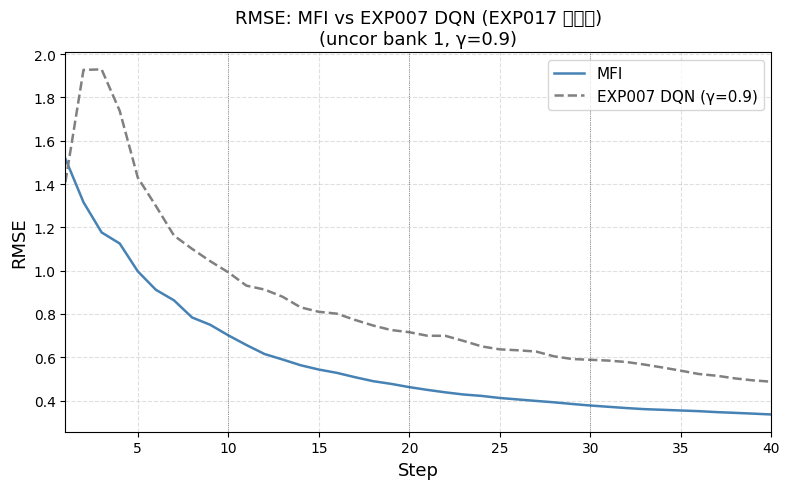

In [4]:
# ---- EXP007 のみ存在する gamma も単独プロット（参考用）----
exp007_only = sorted(set(exp007_files) - set(exp017_files), key=float)

for gamma in exp007_only:
    dqn007 = pd.read_csv(exp007_files[gamma])

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(mfi['step'],    mfi['RMSE'],    label='MFI',
            color='steelblue', linewidth=1.8)
    ax.plot(dqn007['step'], dqn007['RMSE'], label=f'EXP007 DQN (γ={gamma})',
            color='gray', linewidth=1.8, linestyle='--')

    for s in KEY_STEPS:
        ax.axvline(s, color='black', linewidth=0.6, linestyle=':', alpha=0.5)

    ax.set_xlabel('Step', fontsize=13)
    ax.set_ylabel('RMSE', fontsize=13)
    ax.set_title(
        f'RMSE: MFI vs EXP007 DQN (EXP017 未実行)'
        f'\n(uncor bank {bank_id}, γ={gamma})',
        fontsize=13,
    )
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.set_xlim(1, dqn007['step'].max())

    plt.tight_layout()
    plt.show()

In [5]:
# ---- RMSE 比較テーブル（step 10 / 20 / 30 / 40）----
def rmse_at(df: pd.DataFrame, steps: list) -> list:
    """指定ステップの RMSE を返す。該当行がなければ NaN。"""
    return [
        df.loc[df['step'].round().astype(int) == s, 'RMSE']
          .values[0] if (df['step'].round().astype(int) == s).any() else float('nan')
        for s in steps
    ]

rows = []
rows.append({'method': 'MFI', 'gamma': '-', **dict(zip(KEY_STEPS, rmse_at(mfi, KEY_STEPS)))})

for gamma in sorted(set(exp007_files) | set(exp017_files), key=float):
    if gamma in exp007_files:
        df = pd.read_csv(exp007_files[gamma])
        rows.append({'method': 'EXP007 DQN', 'gamma': gamma,
                     **dict(zip(KEY_STEPS, rmse_at(df, KEY_STEPS)))})
    if gamma in exp017_files:
        df = pd.read_csv(exp017_files[gamma])
        rows.append({'method': 'EXP017 DQN+var', 'gamma': gamma,
                     **dict(zip(KEY_STEPS, rmse_at(df, KEY_STEPS)))})

table = pd.DataFrame(rows).set_index(['method', 'gamma'])
table.columns.name = 'step'
print(table.to_string(float_format='{:.3f}'.format))

step                    10    20    30    40
method         gamma                        
MFI            -     0.701 0.462 0.377 0.336
EXP007 DQN     0.1   0.653 0.443 0.367 0.329
EXP017 DQN+var 0.1   0.502 0.380 0.326 0.294
EXP007 DQN     0.3   0.643 0.453 0.387 0.342
               0.6   0.668 0.465 0.383 0.343
               0.9   0.992 0.716 0.589 0.487
